# Shared named regions in native XDMF time series

`WritePointsCells(mesh)` stores fixed point/cell/side regions once with the topology. Every step inherits them, including after flush and append. XML works with the dependency-free single header; the compiled library also supports Binary/HDF. This example renders the final field and verifies the region metadata at each step. See Python's `30_xdmf_series_regions.ipynb` for highlighted region overlays.

In [1]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
using namespace meshioplusplus;
using namespace mio_nb;


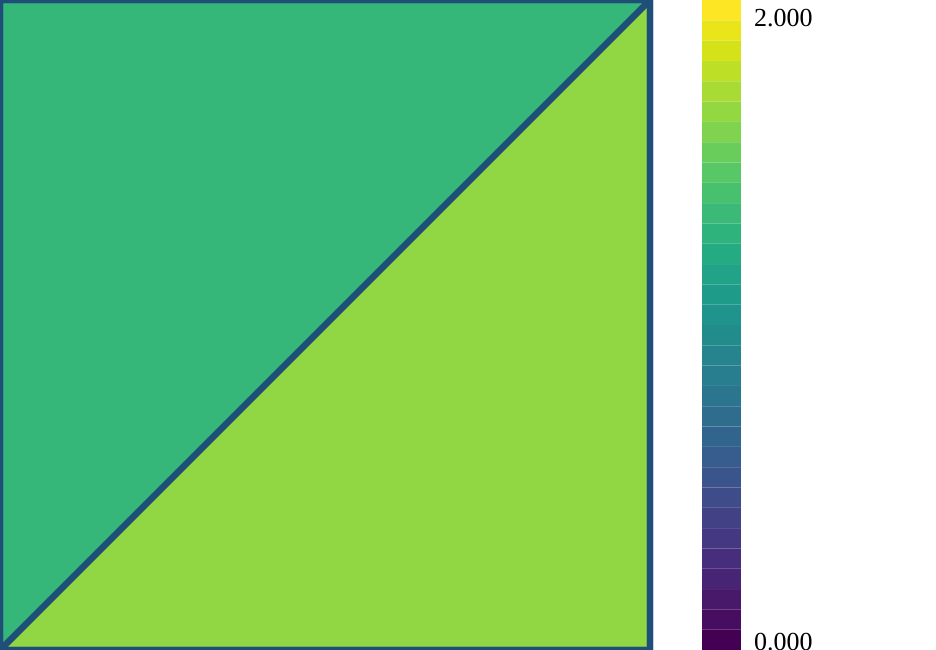

step 0: anchors, tag=7, entries=2
step 0: empty selection, tag=22, entries=0
step 0: boundary, tag=9, entries=2
step 1: anchors, tag=7, entries=2
step 1: empty selection, tag=22, entries=0
step 1: boundary, tag=9, entries=2


In [2]:
Mesh mesh;
NDArray points(DType::Float64, {4, 3});
const double coords[] = {0,0,0, 1,0,0, 1,1,0, 0,1,0};
std::copy(std::begin(coords), std::end(coords), points.As<double>());
mesh.AssignPoints(std::move(points));
NDArray conn(DType::Int64, {2, 3});
const std::int64_t ids[] = {0,1,2, 0,2,3};
std::copy(std::begin(ids), std::end(ids), conn.As<std::int64_t>());
mesh.AddCellBlock("triangle", std::move(conn));
NDArray anchors(DType::Int64, {2});
anchors.As<std::int64_t>()[0] = 0; anchors.As<std::int64_t>()[1] = 3;
mesh.AddRegion(Region("anchors", RegionKind::Point, 0, 7, std::move(anchors)));
NDArray boundary(DType::Int64, {2, 2});
const std::int64_t sides[] = {0,0, 1,1};
std::copy(std::begin(sides), std::end(sides), boundary.As<std::int64_t>());
mesh.AddRegion(Region("boundary", RegionKind::Side, 1, 9, std::move(boundary)));
mesh.AddRegion(Region("empty selection", RegionKind::Cell, 2, 22, NDArray(DType::Int64, {0})));
auto path = std::filesystem::temp_directory_path() / "mio_nb_series_regions.xdmf";
{
    XdmfTimeSeriesWriter writer(path.string(), "XML");
    writer.WritePointsCells(mesh);
    NDArray temperature(DType::Float64, {4});
    for (int i = 0; i < 4; ++i) temperature.As<double>()[i] = coords[3*i];
    mesh.AddPointData("temperature", std::move(temperature));
    writer.WriteData(0., mesh);
    writer.Flush();
    if (read_xdmf(path.string()).NumRegions() != 3) throw std::runtime_error("flush lost regions");
    writer.Finalize();
}
{
    XdmfTimeSeriesWriter writer(path.string(), "XML", -1, XdmfSeriesMode::Append);
    NDArray temperature(DType::Float64, {4});
    for (int i = 0; i < 4; ++i) temperature.As<double>()[i] = coords[3*i] + 1.;
    mesh.AddPointData("temperature", std::move(temperature));
    writer.WriteData(1., mesh);
    writer.Finalize();
}
for (int k = 0; k < 2; ++k) {
    ReadOptions opts; opts.mTimeStep = k;
    auto back = read_xdmf(path.string(), opts);
    if (back.NumRegions() != 3) throw std::runtime_error("shared sets lost");
    for (std::size_t i = 0; i < back.NumRegions(); ++i) {
        const auto& region = back.Region(i);
        std::cout << "step " << k << ": " << region.mName << ", tag=" << region.mTag << ", entries=" << region.NumEntries() << "\n";
    }
    if (k == 1) xcpp::display(render(back, "temperature", "viridis", true, 0, 2, 0, 90, 650));
}
std::filesystem::remove(path);
